# Notebook 13: Combined Approach

Load data and prepare features.

Train four models (Logistic Regression, Random Forest, Gradient Boosting, SVM) using 5-fold leave-one-year-out cross-validation (LOYOCV) over 2014-2018.

Grid search tries different settings and picks the one that performs best.

Balanced accuracy is used to choose the best threshold because it gives equal weight to predicting passes and fails.

Export results to Excel and save charts.

Results will be saved to: C:\Users\Nikita Danvill\OneDrive - University of Otago\Documents\INFO501\Nikita_Danvill_8887029_JupyterNotebooks_INFO501\Results
NOTEBOOK 13_v2: COMBINED APPROACH - NESTED CV + BALANCED ACCURACY THRESHOLD

STEP 1: Loading remediated features...
Feature matrix shape: (1154, 21)
Modeling features (21): ['num_atmp_l1', 'num_atmp_l2', 'num_atmp_l3', 'num_atmp_l4', 'num_atmp_l5', 'num_atmp_l6', 'num_atmp_l7', 'num_atmp_l8', 'num_atmp_l11', 'wk_comp_l1', 'wk_comp_l2', 'wk_comp_l3', 'wk_comp_l4', 'wk_comp_l5', 'wk_comp_l6', 'wk_comp_l7', 'wk_comp_l8', 'total_attempts_3w', 'levels_completed_3w', 'efficiency_3w', 'total_inactivity_adjusted']
Outcome distribution: Pass=887, Fail=267

STEP 4: LOYOCV EVALUATION (2014-2018) WITH PER-FOLD THRESHOLD CALIBRATION

TEST YEAR: 2014
Train size:  912 | Test size: 242
Train fail rate: 24.2%
Test fail rate:  19.0%

--- Logistic Regression ---
  Best hyperparams: {'C': 1.0}
  Calibrated threshold: 0.50
  ⚠  LR COLLAPSE WARNING: 80.6%

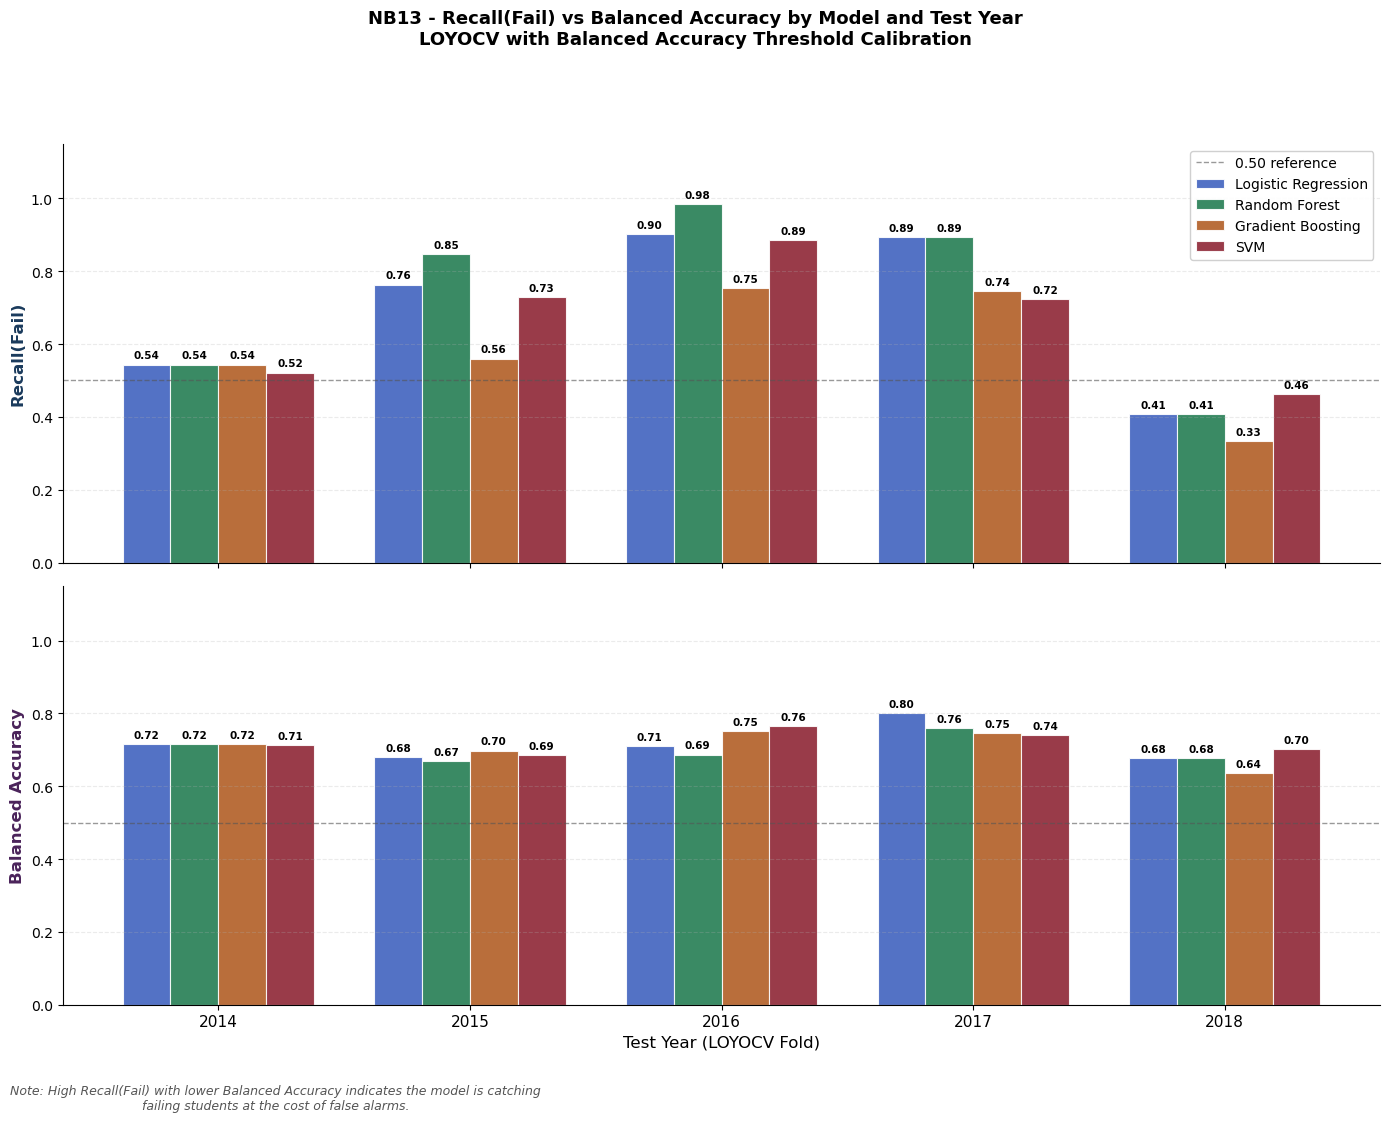

  ✓ Chart 1: Recall(Fail) vs Balanced Accuracy by year saved


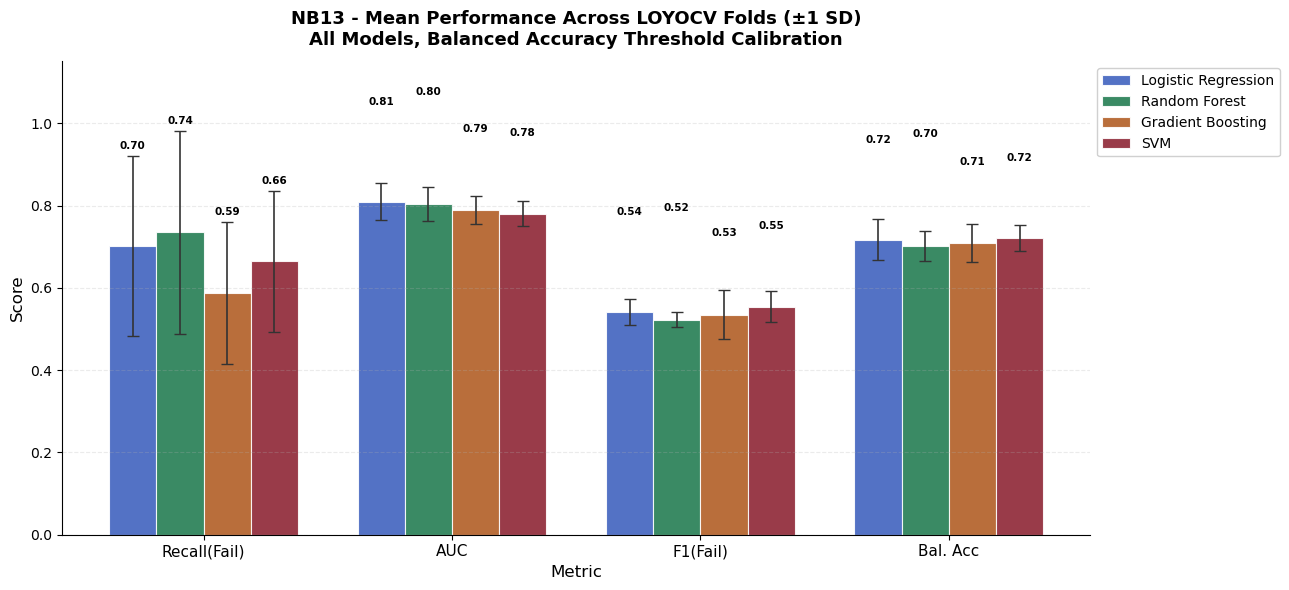

  ✓ Chart 2: Mean metrics comparison saved


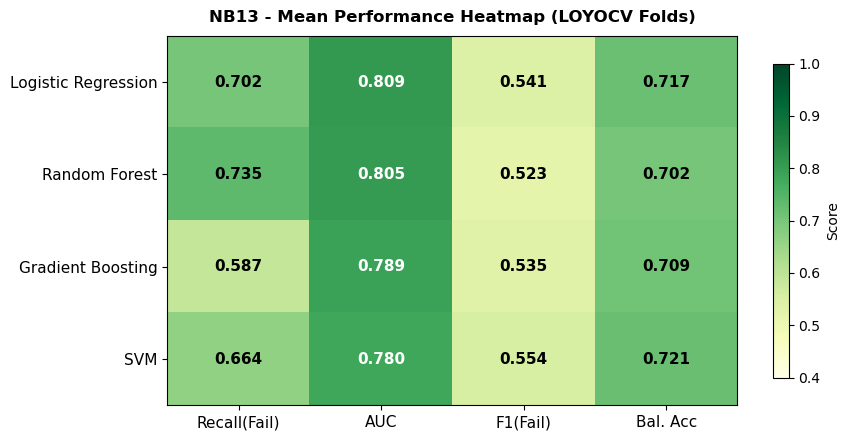

  ✓ Chart 3: Heatmap saved

All NB13 visualizations saved to Results4 folder.

SUMMARY COMPARISON TABLE (all models, mean ± std across LOYOCV folds)


,Model,Recall(Fail),Δ Recall,AUC,Δ AUC,F1(Fail),Δ F1,Bal.Acc,Δ Bal.Acc
0,Logistic Regression,0.702 (±0.219),0.032826,0.809 (±0.046),-0.000013,0.541 (±0.031),-0.019202,0.717 (±0.050),-0.014112
1,Random Forest,0.735 (±0.247),0.119079,0.805 (±0.041),0.023528,0.523 (±0.018),-0.011225,0.702 (±0.037),-0.006456
2,Gradient Boosting,0.587 (±0.173),0.114407,0.789 (±0.033),-0.009126,0.535 (±0.059),0.049439,0.709 (±0.046),0.032758
3,SVM,0.664 (±0.171),0.192748,0.780 (±0.031),-0.002557,0.554 (±0.037),0.074389,0.721 (±0.032),0.043722



NOTEBOOK 13 COMPLETE


In [4]:
# ── Output directory - all results will be saved here ───────────────────────
import os
RESULTS_DIR = os.path.join(os.getcwd(), "Results")
os.makedirs(RESULTS_DIR, exist_ok=True)
print(f"Results will be saved to: {RESULTS_DIR}")

CHARTS_DIR = os.path.join(os.getcwd(), "Charts")
os.makedirs(CHARTS_DIR, exist_ok=True)


import pandas as pd
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.preprocessing import StandardScaler
from sklearn.model_selection import GridSearchCV, train_test_split
from sklearn.metrics import (
    accuracy_score,
    balanced_accuracy_score,
    recall_score,
    f1_score,
    roc_auc_score,
    confusion_matrix
)
from sklearn.metrics import make_scorer
import warnings
warnings.filterwarnings('ignore')

# Custom scorer: recall for the fail class
recall_fail_scorer = make_scorer(recall_score, pos_label=0)

print("="*80)
print("NOTEBOOK 13_v2: COMBINED APPROACH - NESTED CV + BALANCED ACCURACY THRESHOLD")
print("="*80)

# ============================================================================
# STEP 1: LOAD REMEDIATED FEATURES
# ============================================================================
print("\nSTEP 1: Loading remediated features...")

modeling_data = pd.read_excel(
    "modeling_dataset.xlsx"  # relative path - place file in same folder as this notebook
)
y = modeling_data["outcome"]
year_col = modeling_data["year"].copy()

X_remediated = pd.read_csv(os.path.join(RESULTS_DIR, "features_after_zero_ambiguity_fix.csv"))
feature_cols_modeling = [
    col for col in X_remediated.columns
    if col not in ['last_completion_week', 'trailing_gap_weeks']
]
X_model = X_remediated[feature_cols_modeling].copy()

print(f"Feature matrix shape: {X_model.shape}")
print(f"Modeling features ({len(feature_cols_modeling)}): {feature_cols_modeling}")
print(f"Outcome distribution: Pass={sum(y==1)}, Fail={sum(y==0)}")

# ============================================================================
# STEP 2: PARAMETER GRIDS (updated: no C=0.001 for LR)
# ============================================================================
param_grids = {
    'Logistic Regression': {
        'C': [0.01, 0.1, 1.0, 10.0, 100.0]          # removed 0.001
    },
    'Random Forest': {
        'n_estimators': [100, 200, 300],
        'max_depth': [10, 15, None],
        'min_samples_leaf': [1, 3, 5]
    },
    'Gradient Boosting': {
        'n_estimators': [100, 200, 300],
        'learning_rate': [0.01, 0.05, 0.1],
        'max_depth': [3, 4, 5],
        'subsample': [0.8, 1.0]
    },
    'SVM': {
        'C': [0.1, 1.0, 5.0, 10.0],
        'gamma': ['scale', 'auto']
    }
}

candidate_thresholds = [0.30, 0.35, 0.40, 0.45, 0.50, 0.55, 0.60, 0.65, 0.70]

# ============================================================================
# STEP 3: HELPER FUNCTIONS
# ============================================================================
def find_best_threshold(y_prob_val, y_val):
    """Find the threshold that gives the best balanced accuracy on the validation set."""
    best_thresh = 0.50
    best_bal_acc = 0.0
    for t in candidate_thresholds:
        y_hat = (y_prob_val >= t).astype(int)
        ba = balanced_accuracy_score(y_val, y_hat)
        if ba > best_bal_acc:
            best_bal_acc = ba
            best_thresh = t
    return best_thresh

def is_degenerate(y_pred, thresh=0.80):
    """Return True if >80% of predictions are the same class."""
    pct = max(y_pred.mean(), 1 - y_pred.mean())
    return pct > thresh

# ============================================================================
# STEP 4: LOYOCV EVALUATION (2014-2018) WITH PER-FOLD THRESHOLD CALIBRATION
# ============================================================================
print("\n" + "="*80)
print("STEP 4: LOYOCV EVALUATION (2014-2018) WITH PER-FOLD THRESHOLD CALIBRATION")
print("="*80)

test_years = [2014, 2015, 2016, 2017, 2018]
model_names = ['Logistic Regression', 'Random Forest', 'Gradient Boosting', 'SVM']

# Storage
all_results = {m: [] for m in model_names}
all_settings = {m: [] for m in model_names}
baseline_results = {m: [] for m in model_names}   # default hyperparams, threshold 0.50

for test_year in test_years:
    print(f"\n{'='*70}")
    print(f"TEST YEAR: {test_year}")
    print(f"{'='*70}")

    # True LOYOCV: train on all years EXCEPT test year
    train_mask = year_col != test_year
    test_mask  = year_col == test_year

    X_train_full = X_model.loc[train_mask].copy()
    X_test_full  = X_model.loc[test_mask].copy()
    y_train      = y.loc[train_mask].copy()
    y_test       = y.loc[test_mask].copy()

    print(f"Train size: {len(X_train_full):4d} | Test size: {len(X_test_full):3d}")
    print(f"Train fail rate: {(y_train==0).sum()/len(y_train)*100:.1f}%")
    print(f"Test fail rate:  {(y_test==0).sum()/len(y_test)*100:.1f}%")

    # --- Hold out 20% of training set for threshold calibration ---
    X_tr, X_cal, y_tr, y_cal = train_test_split(
        X_train_full, y_train,
        test_size=0.20, stratify=y_train, random_state=42
    )

    # --------------------------------------------------------------
    # LOGISTIC REGRESSION
    # --------------------------------------------------------------
    print("\n--- Logistic Regression ---")
    scaler = StandardScaler()
    Xtr_sc = scaler.fit_transform(X_tr)
    Xcal_sc = scaler.transform(X_cal)

    # 1) Hyperparameter tuning on X_tr
    lr_grid = GridSearchCV(
        LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42),
        param_grids['Logistic Regression'],
        cv=3, scoring=recall_fail_scorer, n_jobs=-1
    )
    lr_grid.fit(Xtr_sc, y_tr)
    best_p = lr_grid.best_params_
    print(f"  Best hyperparams: {best_p}")

    # 2) Fit temporary model on X_tr to get probs on X_cal
    lr_tmp = LogisticRegression(max_iter=1000, class_weight='balanced',
                                random_state=42, **best_p)
    lr_tmp.fit(Xtr_sc, y_tr)
    y_prob_cal = lr_tmp.predict_proba(Xcal_sc)[:, 1]

    # 3) Find best threshold on calibration set
    thresh = find_best_threshold(y_prob_cal, y_cal)
    print(f"  Calibrated threshold: {thresh:.2f}")

    # 4) Refit on full training set
    Xfull_sc = scaler.fit_transform(X_train_full)
    Xtest_sc = scaler.transform(X_test_full)
    lr_final = LogisticRegression(max_iter=1000, class_weight='balanced',
                                  random_state=42, **best_p)
    lr_final.fit(Xfull_sc, y_train)

    # 5) Predict on test year using the per-fold threshold
    y_prob = lr_final.predict_proba(Xtest_sc)[:, 1]
    y_pred = (y_prob >= thresh).astype(int)

    # 6) Metrics
    metrics = {
        'test_year': test_year,
        'threshold': thresh,
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob),
        'recall_fail': recall_score(y_test, y_pred, pos_label=0),
        'f1_fail': f1_score(y_test, y_pred, pos_label=0),
        # FPR = false positive rate (pass students incorrectly flagged as fail)
        'fpr': confusion_matrix(y_test, y_pred)[1,0] / (confusion_matrix(y_test, y_pred)[1,0] + confusion_matrix(y_test, y_pred)[1,1])
    }

    # Collapse detection
    if is_degenerate(y_pred):
        print(f"  ⚠  LR COLLAPSE WARNING: {y_pred.mean()*100:.1f}% fail predictions")
        metrics['degenerate'] = True
    else:
        metrics['degenerate'] = False

    all_results['Logistic Regression'].append(metrics)
    all_settings['Logistic Regression'].append({'test_year': test_year, **best_p, 'threshold': thresh})
    print(f"  Recall(Fail): {metrics['recall_fail']:.3f} | AUC: {metrics['auc']:.3f}")

    # Baseline (default hyperparams, threshold 0.50)
    lr_base = LogisticRegression(max_iter=1000, class_weight='balanced', random_state=42)
    lr_base.fit(Xfull_sc, y_train)
    y_prob_base = lr_base.predict_proba(Xtest_sc)[:, 1]
    y_pred_base = (y_prob_base >= 0.50).astype(int)
    baseline_results['Logistic Regression'].append({
        'test_year': test_year,
        'recall_fail': recall_score(y_test, y_pred_base, pos_label=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_base),
        'f1_fail': f1_score(y_test, y_pred_base, pos_label=0),
        'auc': roc_auc_score(y_test, y_prob_base),
    })

    # --------------------------------------------------------------
    # RANDOM FOREST
    # --------------------------------------------------------------
    print("\n--- Random Forest ---")
    # (No scaling needed)
    Xtr_rf = X_tr.values
    Xcal_rf = X_cal.values

    rf_grid = GridSearchCV(
        RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1),
        param_grids['Random Forest'],
        cv=3, scoring=recall_fail_scorer, n_jobs=-1
    )
    rf_grid.fit(Xtr_rf, y_tr)
    best_p = rf_grid.best_params_
    print(f"  Best hyperparams: {best_p}")

    rf_tmp = RandomForestClassifier(class_weight='balanced', random_state=42, **best_p)
    rf_tmp.fit(Xtr_rf, y_tr)
    y_prob_cal = rf_tmp.predict_proba(Xcal_rf)[:, 1]
    thresh = find_best_threshold(y_prob_cal, y_cal)
    print(f"  Calibrated threshold: {thresh:.2f}")

    Xfull_rf = X_train_full.values
    Xtest_rf = X_test_full.values
    rf_final = RandomForestClassifier(class_weight='balanced', random_state=42, **best_p)
    rf_final.fit(Xfull_rf, y_train)

    y_prob = rf_final.predict_proba(Xtest_rf)[:, 1]
    y_pred = (y_prob >= thresh).astype(int)

    metrics = {
        'test_year': test_year,
        'threshold': thresh,
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob),
        'recall_fail': recall_score(y_test, y_pred, pos_label=0),
        'f1_fail': f1_score(y_test, y_pred, pos_label=0),
        # FPR = false positive rate (pass students incorrectly flagged as fail)
        'fpr': confusion_matrix(y_test, y_pred)[1,0] / (confusion_matrix(y_test, y_pred)[1,0] + confusion_matrix(y_test, y_pred)[1,1])
    }
    all_results['Random Forest'].append(metrics)
    all_settings['Random Forest'].append({'test_year': test_year, **best_p, 'threshold': thresh})
    print(f"  Recall(Fail): {metrics['recall_fail']:.3f} | AUC: {metrics['auc']:.3f}")

    # Baseline RF
    rf_base = RandomForestClassifier(class_weight='balanced', random_state=42, n_jobs=-1)
    rf_base.fit(Xfull_rf, y_train)
    y_prob_base = rf_base.predict_proba(Xtest_rf)[:, 1]
    y_pred_base = (y_prob_base >= 0.50).astype(int)
    baseline_results['Random Forest'].append({
        'test_year': test_year,
        'recall_fail': recall_score(y_test, y_pred_base, pos_label=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_base),
        'f1_fail': f1_score(y_test, y_pred_base, pos_label=0),
        'auc': roc_auc_score(y_test, y_prob_base),
    })

    # --------------------------------------------------------------
    # GRADIENT BOOSTING
    # --------------------------------------------------------------
    print("\n--- Gradient Boosting ---")
    Xtr_gb = X_tr.values
    Xcal_gb = X_cal.values

    gb_grid = GridSearchCV(
        GradientBoostingClassifier(random_state=42),
        param_grids['Gradient Boosting'],
        cv=3, scoring=recall_fail_scorer, n_jobs=-1
    )
    gb_grid.fit(Xtr_gb, y_tr)
    best_p = gb_grid.best_params_
    print(f"  Best hyperparams: {best_p}")

    gb_tmp = GradientBoostingClassifier(random_state=42, **best_p)
    gb_tmp.fit(Xtr_gb, y_tr)
    y_prob_cal = gb_tmp.predict_proba(Xcal_gb)[:, 1]
    thresh = find_best_threshold(y_prob_cal, y_cal)
    print(f"  Calibrated threshold: {thresh:.2f}")

    Xfull_gb = X_train_full.values
    Xtest_gb = X_test_full.values
    gb_final = GradientBoostingClassifier(random_state=42, **best_p)
    gb_final.fit(Xfull_gb, y_train)

    y_prob = gb_final.predict_proba(Xtest_gb)[:, 1]
    y_pred = (y_prob >= thresh).astype(int)

    metrics = {
        'test_year': test_year,
        'threshold': thresh,
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob),
        'recall_fail': recall_score(y_test, y_pred, pos_label=0),
        'f1_fail': f1_score(y_test, y_pred, pos_label=0),
        # FPR = false positive rate (pass students incorrectly flagged as fail)
        'fpr': confusion_matrix(y_test, y_pred)[1,0] / (confusion_matrix(y_test, y_pred)[1,0] + confusion_matrix(y_test, y_pred)[1,1])
    }
    all_results['Gradient Boosting'].append(metrics)
    all_settings['Gradient Boosting'].append({'test_year': test_year, **best_p, 'threshold': thresh})
    print(f"  Recall(Fail): {metrics['recall_fail']:.3f} | AUC: {metrics['auc']:.3f}")

    # Baseline GB
    gb_base = GradientBoostingClassifier(random_state=42)
    gb_base.fit(Xfull_gb, y_train)
    y_prob_base = gb_base.predict_proba(Xtest_gb)[:, 1]
    y_pred_base = (y_prob_base >= 0.50).astype(int)
    baseline_results['Gradient Boosting'].append({
        'test_year': test_year,
        'recall_fail': recall_score(y_test, y_pred_base, pos_label=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_base),
        'f1_fail': f1_score(y_test, y_pred_base, pos_label=0),
        'auc': roc_auc_score(y_test, y_prob_base),
    })

    # --------------------------------------------------------------
    # SVM
    # --------------------------------------------------------------
    print("\n--- SVM ---")
    scaler_svm = StandardScaler()
    Xtr_sc_svm = scaler_svm.fit_transform(X_tr)
    Xcal_sc_svm = scaler_svm.transform(X_cal)

    svm_grid = GridSearchCV(
        SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42),
        param_grids['SVM'],
        cv=3, scoring=recall_fail_scorer, n_jobs=-1
    )
    svm_grid.fit(Xtr_sc_svm, y_tr)
    best_p = svm_grid.best_params_
    print(f"  Best hyperparams: {best_p}")

    svm_tmp = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42, **best_p)
    svm_tmp.fit(Xtr_sc_svm, y_tr)
    y_prob_cal = svm_tmp.predict_proba(Xcal_sc_svm)[:, 1]
    thresh = find_best_threshold(y_prob_cal, y_cal)
    print(f"  Calibrated threshold: {thresh:.2f}")

    Xfull_sc_svm = scaler_svm.fit_transform(X_train_full)
    Xtest_sc_svm = scaler_svm.transform(X_test_full)
    svm_final = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42, **best_p)
    svm_final.fit(Xfull_sc_svm, y_train)

    y_prob = svm_final.predict_proba(Xtest_sc_svm)[:, 1]
    y_pred = (y_prob >= thresh).astype(int)

    metrics = {
        'test_year': test_year,
        'threshold': thresh,
        'accuracy': accuracy_score(y_test, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred),
        'auc': roc_auc_score(y_test, y_prob),
        'recall_fail': recall_score(y_test, y_pred, pos_label=0),
        'f1_fail': f1_score(y_test, y_pred, pos_label=0),
        # FPR = false positive rate (pass students incorrectly flagged as fail)
        'fpr': confusion_matrix(y_test, y_pred)[1,0] / (confusion_matrix(y_test, y_pred)[1,0] + confusion_matrix(y_test, y_pred)[1,1])
    }
    all_results['SVM'].append(metrics)
    all_settings['SVM'].append({'test_year': test_year, **best_p, 'threshold': thresh})
    print(f"  Recall(Fail): {metrics['recall_fail']:.3f} | AUC: {metrics['auc']:.3f}")

    # Baseline SVM
    svm_base = SVC(kernel='rbf', class_weight='balanced', probability=True, random_state=42)
    svm_base.fit(Xfull_sc_svm, y_train)
    y_prob_base = svm_base.predict_proba(Xtest_sc_svm)[:, 1]
    y_pred_base = (y_prob_base >= 0.50).astype(int)
    baseline_results['SVM'].append({
        'test_year': test_year,
        'recall_fail': recall_score(y_test, y_pred_base, pos_label=0),
        'balanced_accuracy': balanced_accuracy_score(y_test, y_pred_base),
        'f1_fail': f1_score(y_test, y_pred_base, pos_label=0),
        'auc': roc_auc_score(y_test, y_prob_base),
    })

# ============================================================================
# STEP 5: CREATE SUMMARY TABLES FOR EXCEL
# ============================================================================
print("\nCreating summary tables...")

from openpyxl import Workbook
from openpyxl.styles import Font, PatternFill, Alignment, Border, Side

wb = Workbook()
wb.remove(wb.active)

for model_name in model_names:
    ws = wb.create_sheet(model_name)

    # Performance per year + summary
    results_df = pd.DataFrame(all_results[model_name])
    baseline_df = pd.DataFrame(baseline_results[model_name])

    # Mean & std (excluding degenerate folds if needed - here we keep all)
    mean = results_df[['recall_fail', 'auc', 'f1_fail', 'balanced_accuracy', 'fpr']].mean()
    std  = results_df[['recall_fail', 'auc', 'f1_fail', 'balanced_accuracy', 'fpr']].std()
    base_mean = baseline_df[['recall_fail', 'auc', 'f1_fail', 'balanced_accuracy']].mean()

    # Build performance table
    perf_data = []
    for _, row in results_df.iterrows():
        perf_data.append([row['test_year'], row['threshold'],
                          row['recall_fail'], row['auc'],
                          row['f1_fail'], row['balanced_accuracy'], row['fpr']])
    perf_data.append(['Mean', np.nan,
                      f"{mean['recall_fail']:.3f} (±{std['recall_fail']:.3f})",
                      f"{mean['auc']:.3f} (±{std['auc']:.3f})",
                      f"{mean['f1_fail']:.3f} (±{std['f1_fail']:.3f})",
                      f"{mean['balanced_accuracy']:.3f} (±{std['balanced_accuracy']:.3f})",
                      f"{mean['fpr']:.3f} (±{std['fpr']:.3f})"])
    perf_data.append(['Std',  np.nan, std['recall_fail'],  std['auc'],
                      std['f1_fail'], std['balanced_accuracy'], std['fpr']])
    perf_data.append(['vs Baseline', np.nan,
                      mean['recall_fail'] - base_mean['recall_fail'],
                      mean['auc'] - base_mean['auc'],
                      mean['f1_fail'] - base_mean['f1_fail'],
                      mean['balanced_accuracy'] - base_mean['balanced_accuracy'],
                      np.nan])

    perf_columns = ['Year', 'Threshold', 'Recall(Fail)', 'AUC', 'F1(Fail)', 'Bal.Acc', 'FPR']
    df_perf = pd.DataFrame(perf_data, columns=perf_columns)

    # Write to worksheet - headers first (row 1), data from row 2 onward
    # (Previously data started at row 1 and the header loop overwrote row 1,
    #  silently dropping the 2014 fold result.)
    for c, col in enumerate(perf_columns, start=1):
        ws.cell(1, c).value = col
        ws.cell(1, c).font = Font(bold=True)
    for r, row in enumerate(df_perf.values, start=2):
        for c, val in enumerate(row, start=1):
            ws.cell(r, c, value=val)

    # Hyperparameter settings per fold
    settings_df = pd.DataFrame(all_settings[model_name])
    settings_start_row = len(df_perf) + 4  # +1 for header row now written separately
    ws.cell(settings_start_row, 1, value="Hyperparameters per fold").font = Font(bold=True)
    for r, row in enumerate(settings_df.values, start=settings_start_row+1):
        for c, val in enumerate(row, start=1):
            ws.cell(r, c, value=val)
    for c, col in enumerate(settings_df.columns, start=1):
        ws.cell(settings_start_row, c).value = col
        ws.cell(settings_start_row, c).font = Font(bold=True)

    # Adjust column widths
    for col in range(1, 8):
        ws.column_dimensions[chr(64+col)].width = 15

# ============================================================================
# STEP 6: SUMMARY COMPARISON SHEET
# ============================================================================
print("\nCreating summary comparison sheet...")
summary_ws = wb.create_sheet("Summary Comparison", 0)

summary_ws.cell(1, 1, "NOTEBOOK 13: SUMMARY COMPARISON").font = Font(bold=True, size=12)
summary_ws.cell(3, 1, "Mean Performance Across Test Years (2014-2018)").font = Font(bold=True)

comp_data = []
for model_name in model_names:
    results_df = pd.DataFrame(all_results[model_name])
    baseline_df = pd.DataFrame(baseline_results[model_name])

    mean_recall = results_df['recall_fail'].mean()
    mean_auc = results_df['auc'].mean()
    mean_f1 = results_df['f1_fail'].mean()
    mean_bal = results_df['balanced_accuracy'].mean()

    base_recall = baseline_df['recall_fail'].mean()
    base_auc = baseline_df['auc'].mean()
    base_f1 = baseline_df['f1_fail'].mean()
    base_bal = baseline_df['balanced_accuracy'].mean()

    std_recall = results_df['recall_fail'].std()
    std_auc    = results_df['auc'].std()
    std_f1     = results_df['f1_fail'].std()
    std_bal    = results_df['balanced_accuracy'].std()

    comp_data.append([
        model_name,
        f"{mean_recall:.3f} (±{std_recall:.3f})", mean_recall - base_recall,
        f"{mean_auc:.3f}  (±{std_auc:.3f})",      mean_auc - base_auc,
        f"{mean_f1:.3f}  (±{std_f1:.3f})",        mean_f1 - base_f1,
        f"{mean_bal:.3f} (±{std_bal:.3f})",        mean_bal - base_bal
    ])

comp_columns = [
    'Model', 'Recall(Fail)', 'Δ Recall', 'AUC', 'Δ AUC',
    'F1(Fail)', 'Δ F1', 'Bal.Acc', 'Δ Bal.Acc'
]
df_comp = pd.DataFrame(comp_data, columns=comp_columns)

for r, row in enumerate(df_comp.values, start=5):
    for c, val in enumerate(row, start=1):
        summary_ws.cell(r, c, value=val)
for c, col in enumerate(comp_columns, start=1):
    summary_ws.cell(4, c, value=col).font = Font(bold=True)

# Column widths
for c in range(1, 10):
    summary_ws.column_dimensions[chr(64+c)].width = 18

# ============================================================================
# STEP 7: EXPORT
# ============================================================================
wb.save(os.path.join(RESULTS_DIR, "Notebook_13_Combined_Approach_Results.xlsx"))
print(f"\n✓ Saved: {os.path.join(RESULTS_DIR, 'Notebook_13_Combined_Approach_Results.xlsx')}")

# ============================================================================
# STEP 8: CONSOLE SUMMARY
# ============================================================================
print("\n" + "="*80)
print("FINAL SUMMARY")
print("="*80)
print(f"\n{'Model':<25} {'Mean Recall(Fail)':<20} {'vs Baseline':<15}")
print("-"*60)
for model_name in model_names:
    results_df = pd.DataFrame(all_results[model_name])
    baseline_df = pd.DataFrame(baseline_results[model_name])
    mean_recall = results_df['recall_fail'].mean()
    base_recall = baseline_df['recall_fail'].mean()
    impr = mean_recall - base_recall
    arrow = "↑" if impr > 0.01 else ("↓" if impr < -0.01 else "→")
    print(f"{model_name:<25} {mean_recall:.3f}  {arrow} {impr:+.3f}")


# ══════════════════════════════════════════════════════════════════════════════
# STEP 9: VISUALIZATIONS
# ══════════════════════════════════════════════════════════════════════════════
print("\nSTEP 9: Generating visualizations...")
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

try:
    from IPython.display import display as ipy_display
except ImportError:
    ipy_display = lambda x: None

COLORS = {
    'Logistic Regression': '#3B5EBD',
    'Random Forest':       '#1E7A4E',
    'Gradient Boosting':   '#B05A20',
    'SVM':                 '#8B2030',
}

# ── CHART 1: Recall(Fail) AND Balanced Accuracy per model per test year ────────
# Two-panel chart: top = Recall(Fail), bottom = Balanced Accuracy, same scale
fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(14, 11), sharex=True)

x     = np.arange(len(test_years))
width = 0.19

for panel_idx, (ax, metric_key, metric_label, y_label_color) in enumerate([
        (ax_top, 'recall_fail',       'Recall(Fail)',       '#1A3A5C'),
        (ax_bot, 'balanced_accuracy', 'Balanced Accuracy',  '#4A235A'),
]):
    for i, model_name in enumerate(model_names):
        vals   = [r[metric_key] for r in all_results[model_name]]
        offset = (i - 1.5) * width
        bars   = ax.bar(x + offset, vals, width,
                        label=model_name if panel_idx == 0 else '_nolegend_',
                        color=COLORS[model_name], alpha=0.88,
                        edgecolor='white', linewidth=0.8)
        for bar, val in zip(bars, vals):
            ax.text(bar.get_x() + bar.get_width() / 2,
                    bar.get_height() + 0.012,
                    f'{val:.2f}', ha='center', va='bottom',
                    fontsize=7.5, fontweight='bold')

    ax.axhline(0.50, color='#555555', linestyle='--', linewidth=1,
               alpha=0.6, label='0.50 reference' if panel_idx == 0 else '_nolegend_')
    ax.set_ylabel(metric_label, fontsize=12, color=y_label_color, fontweight='bold')
    ax.set_ylim(0, 1.15)
    ax.grid(axis='y', alpha=0.25, linestyle='--')
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.set_xticks(x)
    ax.set_xticklabels([str(y) for y in test_years], fontsize=11)

# Shared title and legend
fig.suptitle('NB13 - Recall(Fail) vs Balanced Accuracy by Model and Test Year\n'
             'LOYOCV with Balanced Accuracy Threshold Calibration',
             fontsize=13, fontweight='bold', y=1.01)
ax_top.legend(loc='upper right', framealpha=0.92, fontsize=10)
ax_bot.set_xlabel('Test Year (LOYOCV Fold)', fontsize=12)

# Annotation: if Recall is high but Bal.Acc dips, this reveals threshold trade-offs
fig.text(0.2, 0.02,
         'Note: High Recall(Fail) with lower Balanced Accuracy indicates the model is catching failing students at the cost of false alarms.',
         va='center', ha='center', fontsize=9, color='#555555',
         style='italic', wrap=True)

fig.tight_layout(rect=[0, 0.05, 1, 0.95])
fig.savefig(os.path.join(CHARTS_DIR, 'NB13_recall_vs_balacc_by_year.png'), dpi=150, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print("  ✓ Chart 1: Recall(Fail) vs Balanced Accuracy by year saved")

# ── CHART 2: All metrics - mean across folds, grouped bar chart ──────────────
metrics_keys   = ['recall_fail', 'auc', 'f1_fail', 'balanced_accuracy']
metrics_labels = ['Recall(Fail)', 'AUC', 'F1(Fail)', 'Bal. Acc']

fig, ax = plt.subplots(figsize=(13, 6))
x2     = np.arange(len(metrics_labels))
width2 = 0.19
for i, model_name in enumerate(model_names):
    df_m   = pd.DataFrame(all_results[model_name])
    means  = [df_m[k].mean() for k in metrics_keys]
    stds   = [df_m[k].std()  for k in metrics_keys]
    offset = (i - 1.5) * width2
    bars   = ax.bar(x2 + offset, means, width2,
                    yerr=stds, capsize=4,
                    label=model_name, color=COLORS[model_name],
                    alpha=0.88, edgecolor='white', linewidth=0.8,
                    error_kw={'elinewidth': 1.2, 'ecolor': '#333333'})
    for bar, val in zip(bars, means):
        ax.text(bar.get_x() + bar.get_width() / 2,
                bar.get_height() + max(stds) + 0.012,
                f'{val:.2f}', ha='center', va='bottom', fontsize=7.5, fontweight='bold')

ax.set_xlabel('Metric', fontsize=12)
ax.set_ylabel('Score', fontsize=12)
ax.set_title('NB13 - Mean Performance Across LOYOCV Folds (±1 SD)\n'
             'All Models, Balanced Accuracy Threshold Calibration',
             fontsize=13, fontweight='bold', pad=12)
ax.set_xticks(x2)
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_ylim(0, 1.15)
ax.legend(loc='upper left', bbox_to_anchor=(1, 1), framealpha=0.92, fontsize=10)
ax.grid(axis='y', alpha=0.25, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, 'NB13_metrics_comparison.png'), dpi=150, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print("  ✓ Chart 2: Mean metrics comparison saved")

# ── CHART 3: Metrics heatmap ─────────────────────────────────────────────────
heat_data = np.array([
    [pd.DataFrame(all_results[m])[k].mean() for k in metrics_keys]
    for m in model_names
])

fig, ax = plt.subplots(figsize=(9, 4.5))
im = ax.imshow(heat_data, cmap='YlGn', vmin=0.40, vmax=1.00, aspect='auto')
plt.colorbar(im, ax=ax, shrink=0.85, label='Score')
ax.set_xticks(range(len(metrics_labels)))
ax.set_xticklabels(metrics_labels, fontsize=11)
ax.set_yticks(range(len(model_names)))
ax.set_yticklabels(model_names, fontsize=11)
ax.set_title('NB13 - Mean Performance Heatmap (LOYOCV Folds)',
             fontsize=12, fontweight='bold', pad=10)
for i in range(len(model_names)):
    for j in range(len(metrics_labels)):
        val   = heat_data[i, j]
        color = 'white' if val > 0.74 else 'black'
        ax.text(j, i, f'{val:.3f}', ha='center', va='center',
                fontsize=11, fontweight='bold', color=color)
fig.tight_layout()
fig.savefig(os.path.join(CHARTS_DIR, 'NB13_heatmap.png'), dpi=150, bbox_inches='tight')
ipy_display(fig)
plt.close(fig)
print("  ✓ Chart 3: Heatmap saved")
print("\nAll NB13 visualizations saved to Results4 folder.")

# ── Display summary in Jupyter output ────────────────────────────────────────
print("\n" + "="*80)
print("SUMMARY COMPARISON TABLE (all models, mean ± std across LOYOCV folds)")
print("="*80)
try:
    from IPython.display import display as ipy_display
    comp_display = df_comp.copy()
    ipy_display(comp_display.style.set_caption("NB13: Summary Comparison")
                .set_table_styles([{'selector': 'th', 'props': [('background-color', '#1A3A5C'), ('color', 'white')]}])
                .set_properties(**{'text-align': 'center'}))
except Exception:
    print(df_comp.to_string(index=False))

print("\n" + "="*80)
print("NOTEBOOK 13 COMPLETE")
print("="*80)


# References

- Scikit-learn Documentation: https://scikit-learn.org/stable/
- Grid Search: https://scikit-learn.org/stable/modules/grid_search.html
- Balanced Accuracy: https://scikit-learn.org/stable/modules/generated/sklearn.metrics.balanced_accuracy_score.html
- Logistic Regression: https://scikit-learn.org/stable/modules/generated/sklearn.linear_model.LogisticRegression.html
- Random Forest: https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestClassifier.html
- SVM: https://scikit-learn.org/stable/modules/svm.html